# Train: Auto MPG MLP Regression

Trains a small Keras MLP to predict fuel economy (MPG) from car features.
Outputs two artifacts that `predict.py` (one directory up) loads at runtime:

- `../model/auto_mpg_mlp/` -- a TensorFlow SavedModel
- `../model/feature_columns.json` -- the exact, ordered list of input feature names the model expects

Run all cells top to bottom. The last cell reloads the saved model and
asserts it agrees with `feature_columns.json` before declaring success --
if that cell errors, do not commit the artifacts, something's inconsistent.

In [2]:
import json
import os

import numpy as np
import pandas as pd
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


## 1. Download and load the dataset

Auto MPG dataset (UCI). Downloaded once and cached by Keras under `~/.keras/datasets/`.

In [3]:
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = [
    "MPG", "Cylinders", "Displacement", "Horsepower", "Weight",
    "Acceleration", "Model Year", "Origin",
]

raw_dataset = pd.read_csv(
    url,
    names=column_names,
    na_values="?",
    comment="\t",
    sep=" ",
    skipinitialspace=True,
)

print(raw_dataset.shape)
raw_dataset.head()

(398, 8)


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


## 2. Clean and encode

- Drop rows with missing values (a handful of `Horsepower` entries are `?`).
- `Origin` is a categorical code (1/2/3) -> map to names -> one-hot encode.
- `FEATURE_COLUMNS` below is the **single source of truth** for input order.
  It gets saved to `feature_columns.json` at the end of this notebook, and
  `predict.py` reads that file rather than hardcoding this list -- so the
  model and the column order can never silently drift apart.

In [4]:
dataset = raw_dataset.dropna().copy()

origin_map = {1: "USA", 2: "Europe", 3: "Japan"}
dataset["Origin"] = dataset["Origin"].map(origin_map)
dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="Origin")

FEATURE_COLUMNS = [
    "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration",
    "Model Year", "Origin_USA", "Origin_Europe", "Origin_Japan",
]

# Sanity check before going further: if get_dummies produced different
# column names than expected (e.g. a typo in origin_map, or an Origin
# value that wasn't 1/2/3), fail now with a clear message instead of a
# confusing KeyError three cells down.
missing_cols = [c for c in FEATURE_COLUMNS if c not in dataset.columns]
if missing_cols:
    raise ValueError(
        f"Expected one-hot columns not found in dataset: {missing_cols}. "
        f"Dataset columns are: {list(dataset.columns)}"
    )

dataset = dataset[FEATURE_COLUMNS + ["MPG"]]
dataset.head()

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_USA,Origin_Europe,Origin_Japan,MPG
0,8,307.0,130.0,3504.0,12.0,70,True,False,False,18.0
1,8,350.0,165.0,3693.0,11.5,70,True,False,False,15.0
2,8,318.0,150.0,3436.0,11.0,70,True,False,False,18.0
3,8,304.0,150.0,3433.0,12.0,70,True,False,False,16.0
4,8,302.0,140.0,3449.0,10.5,70,True,False,False,17.0


## 3. Train/test split

In [5]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

train_features = train_dataset[FEATURE_COLUMNS].copy()
test_features = test_dataset[FEATURE_COLUMNS].copy()
train_labels = train_dataset["MPG"].copy()
test_labels = test_dataset["MPG"].copy()

print("train:", train_features.shape, " test:", test_features.shape)

train: (314, 9)  test: (78, 9)


## 4. Build the model

Normalization is a **layer inside the model**, not a separate preprocessing
step done by hand in `predict.py`. `Normalization.adapt()` learns the
mean/variance from training data once, here; after that it's baked into
the SavedModel and travels with it automatically -- including later if you
swap this worker for Triton, since Triton loads the SavedModel as-is.

In [6]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features, dtype=np.float32))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(FEATURE_COLUMNS),)),
    normalizer,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1),  # linear output -- regression, not classification
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mean_absolute_error")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,884 (19.08 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 19 (80.00 B)

## 5. Train

Should take well under a minute on CPU -- this is a tiny dataset (~300 rows) and a tiny model.

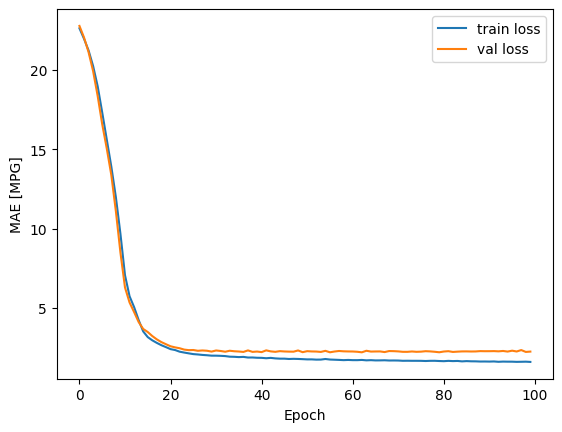

In [7]:
history = model.fit(
    train_features, train_labels,
    epochs=100,
    validation_split=0.2,
    verbose=0,
)

import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MAE [MPG]")
plt.legend()
plt.show()

## 6. Evaluate on the held-out test set

In [8]:
test_mae = model.evaluate(test_features, test_labels, verbose=0)
print(f"Test MAE: {test_mae:.2f} MPG")
print("(For context: typical MPG values in this dataset range roughly 10-45.)")

Test MAE: 1.71 MPG
(For context: typical MPG values in this dataset range roughly 10-45.)


## 7. Save artifacts + verify

Writes both files `predict.py` needs, then **reloads them fresh** (not
the in-memory `model` object) and re-checks them against each other --
this is the same check `predict.py` does at worker startup. If this cell
raises, fix it here before committing anything to git.

In [14]:
MODEL_DIR = "../model/auto_mpg_mlp"
FEATURE_COLUMNS_PATH = "../model/feature_columns.json"

os.makedirs("../model", exist_ok=True)
model.export("../model/auto_mpg_mlp")   # produces a directory, not a file

with open(FEATURE_COLUMNS_PATH, "w") as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)

print(f"Saved model to {MODEL_DIR}")
print(f"Saved feature columns to {FEATURE_COLUMNS_PATH}")


INFO:tensorflow:Assets written to: ../model/auto_mpg_mlp/assets


INFO:tensorflow:Assets written to: ../model/auto_mpg_mlp/assets


Saved artifact at '../model/auto_mpg_mlp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138954478207248: TensorSpec(shape=(1, 9), dtype=tf.float32, name=None)
  138954533322576: TensorSpec(shape=(1, 9), dtype=tf.float32, name=None)
  138954533322192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138954533321040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138954533321232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138954478208208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138954478208592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138954478208976: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved model to ../model/auto_mpg_mlp
Saved feature columns to ../model/feature_columns.json


In [16]:
loaded = tf.saved_model.load("../model/auto_mpg_mlp")
infer = loaded.signatures["serving_default"]
input_name = list(infer.structured_input_signature[1].keys())[0]
output_name = list(infer.structured_outputs.keys())[0]
print("input:", input_name)
print("output:", output_name)
print("input width:", infer.structured_input_signature[1][input_name].shape[-1])
print("OK")

input: keras_tensor
output: output_0
input width: 9
OK


## Next step

From the repo root:

```bash
python smoke_test.py
```

This exercises `predict.py` exactly the way `worker.py` will, with no
Redis/k8s involved -- the fastest way to confirm everything saved
correctly before building the Docker image.